In [3]:
file_path = "/data/demo_data/football/Forwards.csv"

Samples: 76 | Features: 10

--- Factor selection summary ---
Observed eigenvalues (first 10): [4.1269, 1.8566, 0.9961, 0.8046, 0.7112, 0.4775, 0.369, 0.3066, 0.2346, 0.117]
Mean random eigs (first 10)    : [1.6239, 1.4145, 1.2601, 1.1342, 1.0214, 0.9171, 0.8098, 0.7119, 0.6094, 0.4978]
95th pct random eigs (first 10): [1.7933, 1.5437, 1.3606, 1.2193, 1.0976, 0.9955, 0.8886, 0.7979, 0.6945, 0.5868]
Count > mean(random): 2
Count > 95th pct    : 2
Kaiser (>1)         : 2
=> Selected # of factors: 2


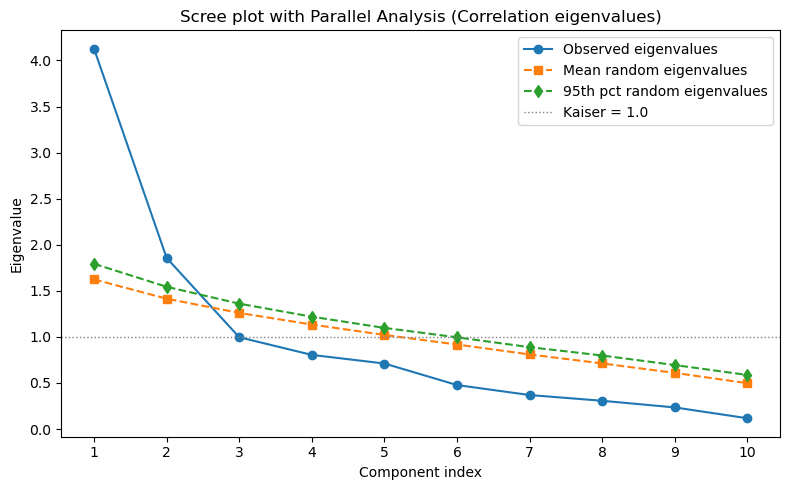

In [4]:

# ------------------------------------------------------------
# Factor Analysis with automatic factor selection (Parallel Analysis)
# Dataset: Forwards.csv
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

# -------------------------------
# 1) Load & prepare the dataset
# -------------------------------


# Use a permissive encoding to avoid decode issues for names with accents
df = pd.read_csv(file_path, encoding="latin1")

# Keep only numeric columns for factor analysis (drop identifiers like player names)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy()

# Handle missing data: drop all-NaN columns, then impute remaining NaNs with column means
X = X.dropna(axis=1, how="all")
X = X.fillna(X.mean(numeric_only=True))

# Standardize the features so FA operates on the correlation structure
scaler = StandardScaler()
Z = scaler.fit_transform(X)

n_samples, n_features = Z.shape
print(f"Samples: {n_samples} | Features: {n_features}")

# -------------------------------------------
# 2) Decide # of factors via Parallel Analysis
#    (Eigenvalues of the correlation matrix)
# -------------------------------------------
def corr_eigenvalues(data_std):
    """
    Compute eigenvalues of the correlation matrix of standardized data.
    data_std must be standardized (zero mean, unit variance per column).
    """
    # Since data are standardized, correlation = covariance
    R = np.corrcoef(data_std, rowvar=False)
    # Use eigvalsh for symmetric matrices (sorted ascending)
    eigvals = np.linalg.eigvalsh(R)
    # Return in descending order
    return eigvals[::-1]

obs_eigvals = corr_eigenvalues(Z)

# Parallel Analysis: simulate random normal data with same shape, standardized per column,
# take eigenvalues of correlation matrices, compare to observed.
n_iter = 500  # increase for more stability if needed
rng = np.random.default_rng(42)
rand_eigs = np.zeros((n_iter, n_features))

for i in range(n_iter):
    R = rng.standard_normal(size=(n_samples, n_features))
    R = (R - R.mean(axis=0)) / R.std(axis=0, ddof=1)  # standardize
    rand_eigs[i, :] = corr_eigenvalues(R)

mean_rand = rand_eigs.mean(axis=0)
p95_rand = np.percentile(rand_eigs, 95, axis=0)

# Counts by different rules
n_factors_mean   = int(np.sum(obs_eigvals > mean_rand))
n_factors_p95    = int(np.sum(obs_eigvals > p95_rand))
n_factors_kaiser = int(np.sum(obs_eigvals > 1.0))  # Kaiser rule on correlation eigenvalues

# Conservative default: use 95th percentile; fallback to mean rule, at least 1 factor
best_n_factors = n_factors_p95 if n_factors_p95 >= 1 else max(1, n_factors_mean)

print("\n--- Factor selection summary ---")
print(f"Observed eigenvalues (first 10): {np.round(obs_eigvals[:10], 4).tolist()}")
print(f"Mean random eigs (first 10)    : {np.round(mean_rand[:10], 4).tolist()}")
print(f"95th pct random eigs (first 10): {np.round(p95_rand[:10], 4).tolist()}")
print(f"Count > mean(random): {n_factors_mean}")
print(f"Count > 95th pct    : {n_factors_p95}")
print(f"Kaiser (>1)         : {n_factors_kaiser}")
print(f"=> Selected # of factors: {best_n_factors}")

# Optional: Scree + Parallel Analysis plot
plt.figure(figsize=(8, 5))
idx = np.arange(1, n_features + 1)
plt.plot(idx, obs_eigvals, "o-", label="Observed eigenvalues")
plt.plot(idx, mean_rand, "s--", label="Mean random eigenvalues")
plt.plot(idx, p95_rand, "d--", label="95th pct random eigenvalues")
plt.axhline(1.0, color="gray", lw=1, ls=":", label="Kaiser = 1.0")
plt.xticks(idx)
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot with Parallel Analysis (Correlation eigenvalues)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3) Fit Factor Analysis (Maximum Likelihood) + Varimax
# ---------------------------------------------------
fa = FactorAnalysis(n_components=best_n_factors, random_state=42)
fa.fit(Z)

# Unrotated loadings: shape (n_features, n_factors)
loadings = fa.components_.T

# Varimax rotation for better interpretability (orthogonal)
def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    """
    Varimax rotation (orthogonal).
    Phi: loadings matrix (features x factors)
    Returns: (rotated_loadings, rotation_matrix)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda ** 3 - (gamma / p) * Lambda @ np.diag(np.sum(Lambda ** 2, axis=0)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d / d_old) < (1 + tol):
            break
    return Phi @ R, R

rot_loadings, R = varimax(loadings)

# Communalities and uniquenesses.
# Under standardization, total variance per variable≈1.
communalities = (rot_loadings ** 2).sum(axis=1)
uniquenesses  = 1 - communalities

# Factor scores: sklearn returns regression scores for the unrotated solution;


Samples: 76 | Features: 10

--- Factor selection summary ---
Observed eigenvalues (first 10): [4.1269, 1.8566, 0.9961, 0.8046, 0.7112, 0.4775, 0.369, 0.3066, 0.2346, 0.117]
Mean random eigs (first 10)    : [1.6239, 1.4145, 1.2601, 1.1342, 1.0214, 0.9171, 0.8098, 0.7119, 0.6094, 0.4978]
95th pct random eigs (first 10): [1.7933, 1.5437, 1.3606, 1.2193, 1.0976, 0.9955, 0.8886, 0.7979, 0.6945, 0.5868]
Count > mean(random): 2
Count > 95th pct    : 2
Kaiser (>1)         : 2
=> Selected # of factors: 2


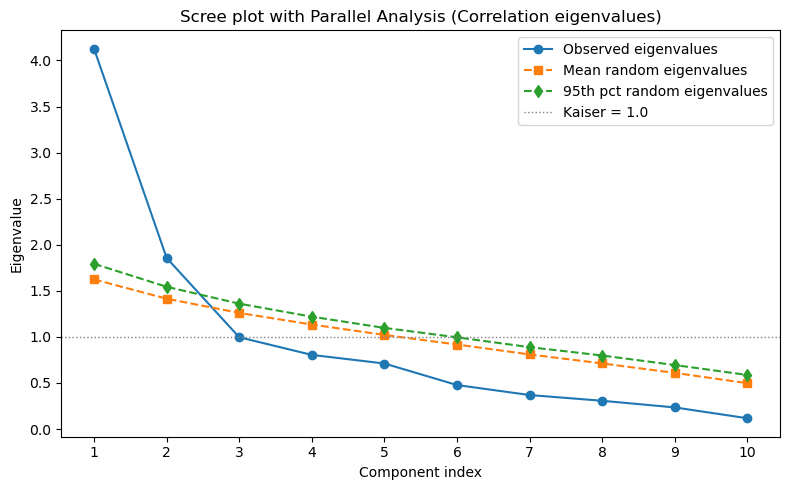


--- Proposed factor names ---
  Factor 1: Final-third creation & link-up
    Top variables: final_third_passes_adjusted_per90, final_third_receptions_adjusted_per90, smart_passes_adjusted_per90, key_passes_adjusted_per90, ground_duels_won_adjusted_per90
  Factor 2: Scoring threat / finishing
    Top variables: goals_adjusted_per90, npxG_adjusted_per90, Minutes, ground_duels_won_adjusted_per90, final_third_passes_adjusted_per90

--- Rotated factor loadings (varimax) ---
                                       Final-third creation & link-up  \
final_third_passes_adjusted_per90                               0.944   
final_third_receptions_adjusted_per90                           0.887   
smart_passes_adjusted_per90                                     0.792   
key_passes_adjusted_per90                                       0.751   
ground_duels_won_adjusted_per90                                 0.641   
air_duels_won_adjusted_per90                                   -0.485   
assists_adjust

In [6]:

# ------------------------------------------------------------
# Factor Analysis with automatic factor naming
# Dataset: Forwards.csv
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

# -------------------------------
# 1) Load & prepare the dataset
# -------------------------------


# Use a permissive encoding to avoid decode issues for names with accents
df = pd.read_csv(file_path, encoding="latin1")

# Keep only numeric columns for factor analysis (drop identifiers like player names)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy()

# Handle missing data: drop all-NaN columns, then impute remaining NaNs with column means
X = X.dropna(axis=1, how="all")
X = X.fillna(X.mean(numeric_only=True))

# Standardize the features so FA operates on the correlation structure
scaler = StandardScaler()
Z = scaler.fit_transform(X)

n_samples, n_features = Z.shape
print(f"Samples: {n_samples} | Features: {n_features}")

# -------------------------------------------
# 2) Decide # of factors via Parallel Analysis
#    (Eigenvalues of the correlation matrix)
# -------------------------------------------
def corr_eigenvalues(data_std):
    """
    Compute eigenvalues of the correlation matrix of standardized data.
    data_std must be standardized (zero mean, unit variance per column).
    """
    R = np.corrcoef(data_std, rowvar=False)
    eigvals = np.linalg.eigvalsh(R)[::-1]  # descending
    return eigvals

obs_eigvals = corr_eigenvalues(Z)

# Parallel Analysis: simulate random normal data with same shape, standardized,
# compare observed correlation eigenvalues to random ones.
n_iter = 500  # increase for more stability if needed
rng = np.random.default_rng(42)
rand_eigs = np.zeros((n_iter, n_features))

for i in range(n_iter):
    Rnd = rng.standard_normal(size=(n_samples, n_features))
    Rnd = (Rnd - Rnd.mean(axis=0)) / Rnd.std(axis=0, ddof=1)  # standardize
    rand_eigs[i, :] = corr_eigenvalues(Rnd)

mean_rand = rand_eigs.mean(axis=0)
p95_rand  = np.percentile(rand_eigs, 95, axis=0)

# Choose count (conservative 95th percentile rule; fallback to mean rule, at least 1)
n_factors_mean   = int(np.sum(obs_eigvals > mean_rand))
n_factors_p95    = int(np.sum(obs_eigvals > p95_rand))
n_factors_kaiser = int(np.sum(obs_eigvals > 1.0))  # Kaiser rule on correlation eigs
best_n_factors   = n_factors_p95 if n_factors_p95 >= 1 else max(1, n_factors_mean)

print("\n--- Factor selection summary ---")
print(f"Observed eigenvalues (first 10): {np.round(obs_eigvals[:10], 4).tolist()}")
print(f"Mean random eigs (first 10)    : {np.round(mean_rand[:10], 4).tolist()}")
print(f"95th pct random eigs (first 10): {np.round(p95_rand[:10], 4).tolist()}")
print(f"Count > mean(random): {n_factors_mean}")
print(f"Count > 95th pct    : {n_factors_p95}")
print(f"Kaiser (>1)         : {n_factors_kaiser}")
print(f"=> Selected # of factors: {best_n_factors}")

# Optional: Scree + Parallel Analysis plot
plt.figure(figsize=(8, 5))
idx = np.arange(1, n_features + 1)
plt.plot(idx, obs_eigvals, "o-", label="Observed eigenvalues")
plt.plot(idx, mean_rand, "s--", label="Mean random eigenvalues")
plt.plot(idx, p95_rand, "d--", label="95th pct random eigenvalues")
plt.axhline(1.0, color="gray", lw=1, ls=":", label="Kaiser = 1.0")
plt.xticks(idx)
plt.xlabel("Component index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot with Parallel Analysis (Correlation eigenvalues)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------
# 3) Fit Factor Analysis (Maximum Likelihood) + Varimax
# ---------------------------------------------------
fa = FactorAnalysis(n_components=best_n_factors, random_state=42)
fa.fit(Z)

# Unrotated loadings: shape (n_features, n_factors)
loadings = fa.components_.T

# Varimax rotation for better interpretability (orthogonal)
def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    """
    Varimax rotation (orthogonal).
    Phi: loadings matrix (features x factors)
    Returns: (rotated_loadings, rotation_matrix)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda ** 3 - (gamma / p) * Lambda @ np.diag(np.sum(Lambda ** 2, axis=0)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d / d_old) < (1 + tol):
            break
    return Phi @ R, R

rot_loadings, R = varimax(loadings)

# Communalities and uniquenesses (since Z is standardized, total variance per variable ~1)
communalities = (rot_loadings ** 2).sum(axis=1)
uniquenesses  = 1 - communalities

# Factor scores: sklearn returns regression scores for the unrotated solution;
# rotate them to align with the rotated loading pattern.
raw_scores = fa.transform(Z)      # (n_samples, n_factors)
rot_scores = raw_scores @ R       # (n_samples, n_factors)

# --------------------------------
# 4) Auto-name the factors (rule-based)
# --------------------------------
feature_names = X.columns.tolist()
factor_names  = [f"Factor_{i+1}" for i in range(best_n_factors)]

loadings_df = pd.DataFrame(rot_loadings, index=feature_names, columns=factor_names)

def suggest_factor_name(var_list):
    """Suggest a factor name from the top-loading variable names."""
    v = [s.lower() for s in var_list]
    # Scoring / finishing
    if any(("goals" in s) or ("npxg" in s) for s in v):
        if any(("assist" in s) or ("key_pass" in s) or ("smart_pass" in s) for s in v):
            return "Scoring & chance creation"
        return "Scoring threat / finishing"
    # Creation / link-up
    if any(("pass" in s) or ("reception" in s) for s in v):
        return "Final-third creation & link-up"
    # Aerial / physical
    if any(("air_duels" in s) for s in v):
        return "Aerial presence"
    if any(("ground_duels" in s) for s in v):
        return "Ball carrying & duels"
    # Fallback
    return "General involvement"

# Build names based on top absolute loadings per factor
proposed_names = []
top_k = 5  # look at top-5 variables by absolute loading to name each factor
for j in range(best_n_factors):
    top_vars = loadings_df.iloc[:, j].abs().sort_values(ascending=False).head(top_k).index.tolist()
    proposed_names.append(suggest_factor_name(top_vars))

# If duplicates occur, make them unique with a suffix
final_names = []
seen = {}
for name in proposed_names:
    if name not in seen:
        seen[name] = 1
        final_names.append(name)
    else:
        seen[name] += 1
        final_names.append(f"{name} ({seen[name]})")

# Apply names
rename_map = dict(zip(loadings_df.columns, final_names))
loadings_df.rename(columns=rename_map, inplace=True)

scores_df = pd.DataFrame(rot_scores, columns=final_names)
if "shortName" in df.columns:
    scores_df.insert(0, "shortName", df["shortName"].values)

commun_df = pd.DataFrame(
    {"Communality": communalities, "Uniqueness": uniquenesses},
    index=feature_names
)

# --------------------------------
# 5) Display results
# --------------------------------
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

print("\n--- Proposed factor names ---")
for j, nm in enumerate(final_names, start=1):
    top_vars = loadings_df[nm].abs().sort_values(ascending=False).head(top_k)
    print(f"  Factor {j}: {nm}")
    print("    Top variables:", ", ".join(top_vars.index.tolist()))

print("\n--- Rotated factor loadings (varimax) ---")
# Sort rows by the factor on which they load most (absolute), then by magnitude
max_idx = np.argmax(np.abs(loadings_df.values), axis=1)
order = np.lexsort((-np.max(np.abs(loadings_df.values), axis=1), max_idx))
print(loadings_df.iloc[order].round(3))

print("\n--- Communalities & Uniquenesses ---")
print(commun_df.round(3))

print("\n--- First 10 observations' (players') factor scores ---")
print(scores_df.head(10).round(3))

# --------------------------------
# 6) (Optional) Save outputs
# --------------------------------
# loadings_df.to_csv("fa_rotated_loadings_named.csv", index=True)
# commun_df.to_csv("fa_communalities_uniquenesses.csv", index=True)
# scores_df.to_csv("fa_rotated_scores_named.csv", index=False)



In [9]:

# ------------------------------------------------------------
# Factor-based clustering with automatic k selection + naming
# Dataset: Forwards.csv
# ------------------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# -------------------------------
# 1) Load and Factor Analysis
# -------------------------------

df = pd.read_csv(file_path, encoding="latin1")

# Numeric features only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy().dropna(axis=1, how="all")
X = X.fillna(X.mean(numeric_only=True))

# Standardize (so FA is on correlation structure)
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# --- Parallel Analysis (95th percentile) to select factor count ---
def corr_eigenvalues(data_std):
    R = np.corrcoef(data_std, rowvar=False)
    return np.linalg.eigvalsh(R)[::-1]

obs_eigvals = corr_eigenvalues(Z)
rng = np.random.default_rng(42)
n_iter = 500
rand_eigs = np.zeros((n_iter, Z.shape[1]))
for i in range(n_iter):
    S = rng.standard_normal(size=Z.shape)
    S = (S - S.mean(axis=0)) / S.std(axis=0, ddof=1)
    rand_eigs[i, :] = corr_eigenvalues(S)

p95_rand = np.percentile(rand_eigs, 95, axis=0)
n_factors = int(np.sum(obs_eigvals > p95_rand))
n_factors = max(1, n_factors)

# --- Maximum-likelihood FA + Varimax rotation ---
fa = FactorAnalysis(n_components=n_factors, random_state=42).fit(Z)
loadings = fa.components_.T

def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma/p) * Lambda @ np.diag(np.sum(Lambda**2, axis=0)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d/d_old) < (1 + tol):
            break
    return Phi @ R, R

rot_loadings, R = varimax(loadings)
raw_scores = fa.transform(Z)
rot_scores = raw_scores @ R

# Auto-name factors from top-loading variables
feature_names = X.columns.tolist()
L = pd.DataFrame(rot_loadings, index=feature_names, columns=[f"Factor_{i+1}" for i in range(n_factors)])

def suggest_factor_name(var_list):
    vs = [s.lower() for s in var_list]
    if any(("goals" in s) or ("npxg" in s) for s in vs):
        if any(("assist" in s) or ("key_pass" in s) or ("smart_pass" in s) for s in vs):
            return "Scoring & chance creation"
        return "Scoring threat / finishing"
    if any(("pass" in s) or ("reception" in s) for s in vs):
        return "Final-third creation & link-up"
    if any(("air_duels" in s) for s in vs):
        return "Aerial presence"
    if any(("ground_duels" in s) for s in vs):
        return "Ball carrying & duels"
    return "General involvement"

proposed = []
for j in range(n_factors):
    top_vars = L.iloc[:, j].abs().sort_values(ascending=False).head(5).index.tolist()
    proposed.append(suggest_factor_name(top_vars))

# make names unique
final_names, seen = [], {}
for nm in proposed:
    if nm not in seen:
        seen[nm] = 1
        final_names.append(nm)
    else:
        seen[nm] += 1
        final_names.append(f"{nm} ({seen[nm]})")

# -------------------------------
# 2) Cluster analysis on factors
# -------------------------------
# Standardize factor scores for fair Euclidean distance
score_scaler = StandardScaler()
Z_scores = score_scaler.fit_transform(rot_scores)

# Evaluate k = 2..8
ks = list(range(2, min(9, len(df))))
metrics = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(Z_scores)
    metrics.append({
        "k": k,
        "silhouette": silhouette_score(Z_scores, labels),
        "calinski_harabasz": calinski_harabasz_score(Z_scores, labels),
        "davies_bouldin": davies_bouldin_score(Z_scores, labels),
    })
res_df = pd.DataFrame(metrics)

# pick best k: max silhouette; tie-break max CH, then min DB
best = res_df.sort_values(
    ["silhouette", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).iloc[0]
best_k = int(best["k"])

# final model
km = KMeans(n_clusters=best_k, n_init=100, random_state=42)
labels = km.fit_predict(Z_scores)
centroids_z = km.cluster_centers_                           # standardized space
centroids_raw = np.vstack([rot_scores[labels == c].mean(axis=0) for c in range(best_k)])

# -------------------------------
# 3) Name clusters & describe
# -------------------------------
HIGH, LOW = 0.5, -0.5
cluster_names = []
for c in range(best_k):
    z = centroids_z[c]
    f1 = z[0] if len(z) > 0 else 0.0
    f2 = z[1] if len(z) > 1 else 0.0
    if len(z) >= 2:
        if f1 >= HIGH and f2 >= HIGH:
            name = "Dual-threat creators-finishers"
        elif f1 >= HIGH and f2 <= LOW:
            name = "Final-third creators"
        elif f1 <= LOW and f2 >= HIGH:
            name = "Primary finishers"
        elif f1 <= LOW and f2 <= LOW:
            name = "Low-involvement forwards"
        elif f1 <= LOW and (LOW < f2 < HIGH):
            name = "Creation-suppressed forwards"
        elif f2 <= LOW and (LOW < f1 < HIGH):
            name = "Finishing-suppressed forwards"
        elif (LOW < f1 < HIGH) and (LOW < f2 < HIGH):
            name = "Balanced forwards"
        else:
            name = "Creation-leaning forwards" if f1 >= HIGH else ("Finishing-leaning forwards" if f2 >= HIGH else "Mixed-profile forwards")
    else:
        name = "High creators/finishers" if z[0] >= HIGH else ("Low creators/finishers" if z[0] <= LOW else "Balanced involvement")
    cluster_names.append(name)

def describe_cluster(z_centroid, factor_names):
    strength_flag = (np.linalg.norm(z_centroid) > 1.2)
    overview = f"This cluster groups forwards with a {'strong' if strength_flag else 'moderate'} overall profile across the extracted factors."
    strengths = []
    for i, fname in enumerate(factor_names):
        if z_centroid[i] >= HIGH:
            strengths.append(f"above-average {fname.lower()}")
    strengths_sentence = ("They excel in " + ", ".join(strengths) + ".") if strengths else "Their strengths are balanced without standout peaks."
    weaknesses = []
    for i, fname in enumerate(factor_names):
        if z_centroid[i] <= LOW:
            weaknesses.append(f"below-average {fname.lower()}")
    weaknesses_sentence = ("Potential weaknesses include " + ", ".join(weaknesses) + ".") if weaknesses else "No clear weaknesses emerge relative to the sample."
    return overview + " " + strengths_sentence + " " + weaknesses_sentence

descriptions = [describe_cluster(centroids_z[c], final_names) for c in range(best_k)]

# -------------------------------
# 4) Outputs
# -------------------------------
scores_df = pd.DataFrame(rot_scores, columns=final_names)
if "shortName" in df.columns:
    scores_df.insert(0, "shortName", df["shortName"].values)
assignments = scores_df.copy()
assignments["cluster_id"] = labels
assignments["cluster_name"] = assignments["cluster_id"].apply(lambda c: cluster_names[c])
assignments.to_csv("forwards_cluster_assignments_refined.csv", index=False)

cluster_summary = []
for c in range(best_k):
    n_c = int((labels == c).sum())
    entry = {"cluster_id": c, "cluster_name": cluster_names[c], "n_players": n_c}
    for i, fname in enumerate(final_names):
        entry[f"{fname} (z-mean)"] = float(centroids_z[c, i])
        entry[f"{fname} (raw-mean)"] = float(centroids_raw[c, i])
    cluster_summary.append(entry)
pd.DataFrame(cluster_summary).to_csv("forwards_cluster_summary_refined.csv", index=False)

# Print a compact summary
print(f"Selected k = {best_k}")
print(pd.DataFrame(cluster_summary)[['cluster_id','cluster_name','n_players']])
for c, d in enumerate(descriptions):
    print(f"Cluster {c} — {cluster_names[c]}:{d}")


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

Selected k = 6
   cluster_id                    cluster_name  n_players
0           0    Creation-suppressed forwards         22
1           1   Finishing-suppressed forwards         23
2           2       Creation-leaning forwards          3
3           3  Dual-threat creators-finishers          8
4           4      Finishing-leaning forwards         12
5           5   Finishing-suppressed forwards          8
Cluster 0 — Creation-suppressed forwards:This cluster groups forwards with a moderate overall profile across the extracted factors. Their strengths are balanced without standout peaks. Potential weaknesses include below-average final-third creation & link-up.
Cluster 1 — Finishing-suppressed forwards:This cluster groups forwards with a moderate overall profile across the extracted factors. Their strengths are balanced without standout peaks. Potential weaknesses include below-average scoring threat / finishing.
Cluster 2 — Creation-leaning forwards:This cluster groups forwards wi

In [12]:

# ------------------------------------------------------------
# Concise 3-sentence player summary from FA + clustering
# Dataset: Forwards.csv
# ------------------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# -------------------------------
# 0) Configuration
# -------------------------------
CSV_PATH = file_path
PLAYER_NAME = "Pedro"  # <-- change to any shortName in the file
RANDOM_STATE = 42
N_ITER_PARALLEL = 500
K_MIN, K_MAX = 2, 8
HIGH, LOW = 0.5, -0.5  # thresholds for "high"/"low" factor centroid z-values

# Metrics to compute percentile ranks for strengths/weaknesses
METRIC_COLS = [
    "final_third_passes_adjusted_per90",
    "final_third_receptions_adjusted_per90",
    "smart_passes_adjusted_per90",
    "key_passes_adjusted_per90",
    "assists_adjusted_per90",
    "goals_adjusted_per90",
    "npxG_adjusted_per90",
    "air_duels_won_adjusted_per90",
    "ground_duels_won_adjusted_per90",
]

# -------------------------------
# 1) Utilities
# -------------------------------
def corr_eigenvalues(data_std: np.ndarray) -> np.ndarray:
    """Eigenvalues (descending) of correlation matrix for standardized data."""
    R = np.corrcoef(data_std, rowvar=False)
    return np.linalg.eigvalsh(R)[::-1]

def varimax(Phi: np.ndarray, gamma: float = 1.0, q: int = 50, tol: float = 1e-6):
    """Orthogonal varimax rotation for loadings."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.sum(Lambda**2, axis=0)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d / d_old) < (1 + tol):
            break
    return Phi @ R, R

def suggest_factor_name(top_vars):
    """Simple rule-based factor naming."""
    v = [s.lower() for s in top_vars]
    if any(("goals" in s) or ("npxg" in s) for s in v):
        if any(("assist" in s) or ("key_pass" in s) or ("smart_pass" in s) for s in v):
            return "Scoring & chance creation"
        return "Scoring threat / finishing"
    if any(("pass" in s) or ("reception" in s) for s in v):
        return "Final-third creation & link-up"
    if any(("air_duels" in s) for s in v):
        return "Aerial presence"
    if any(("ground_duels" in s) for s in v):
        return "Ball carrying & duels"
    return "General involvement"

def name_cluster_from_centroid(z_centroid: np.ndarray, factor_names):
    """Assign an interpretable cluster name given standardized factor centroids."""
    f1 = z_centroid[0] if len(z_centroid) > 0 else 0.0
    f2 = z_centroid[1] if len(z_centroid) > 1 else 0.0
    if len(z_centroid) >= 2:
        if f1 >= HIGH and f2 >= HIGH:
            return "Dual-threat creators-finishers"
        if f1 >= HIGH and f2 <= LOW:
            return "Final-third creators"
        if f1 <= LOW and f2 >= HIGH:
            return "Primary finishers"
        if f1 <= LOW and f2 <= LOW:
            return "Low-involvement forwards"
        if f1 <= LOW and (LOW < f2 < HIGH):
            return "Creation-suppressed forwards"
        if f2 <= LOW and (LOW < f1 < HIGH):
            return "Finishing-suppressed forwards"
        if (LOW < f1 < HIGH) and (LOW < f2 < HIGH):
            return "Balanced forwards"
        # nuanced cases
        if f1 >= HIGH:
            return "Creation-leaning forwards"
        if f2 >= HIGH:
            return "Finishing-leaning forwards"
        return "Mixed-profile forwards"
    # one-factor fallback
    if f1 >= HIGH:
        return "High creators/finishers"
    if f1 <= LOW:
        return "Low creators/finishers"
    return "Balanced involvement"

def percentile_rank(values: np.ndarray, x: float) -> float:
    """Percentile rank of x among values: percent of values <= x."""
    return float(np.sum(values <= x) / len(values) * 100.0)

# -------------------------------
# 2) Load & prepare data
# -------------------------------
df = pd.read_csv(CSV_PATH, encoding="latin1")
if "shortName" not in df.columns:
    raise ValueError("Column 'shortName' not found in the CSV.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy().dropna(axis=1, how="all")
X = X.fillna(X.mean(numeric_only=True))

# Standardize for FA on correlation structure
scaler = StandardScaler()
Z = scaler.fit_transform(X)

# -------------------------------
# 3) Parallel Analysis -> #Factors
# -------------------------------
obs_eigs = corr_eigenvalues(Z)
rng = np.random.default_rng(RANDOM_STATE)
rand_eigs = np.zeros((N_ITER_PARALLEL, Z.shape[1]))
for i in range(N_ITER_PARALLEL):
    S = rng.standard_normal(size=Z.shape)
    S = (S - S.mean(axis=0)) / S.std(axis=0, ddof=1)
    rand_eigs[i, :] = corr_eigenvalues(S)
p95_rand = np.percentile(rand_eigs, 95, axis=0)
n_factors = int(np.sum(obs_eigs > p95_rand))
n_factors = max(1, n_factors)

# -------------------------------
# 4) Factor Analysis + varimax
# -------------------------------
fa = FactorAnalysis(n_components=n_factors, random_state=RANDOM_STATE).fit(Z)
loadings = fa.components_.T
rot_loadings, R = varimax(loadings)
raw_scores = fa.transform(Z)
rot_scores = raw_scores @ R

# Factor naming (top 5 variables by absolute loading)
feature_names = X.columns.tolist()
Ldf = pd.DataFrame(rot_loadings, index=feature_names, columns=[f"Factor_{i+1}" for i in range(n_factors)])

proposed_names = []
for j in range(n_factors):
    top_vars = Ldf.iloc[:, j].abs().sort_values(ascending=False).head(5).index.tolist()
    proposed_names.append(suggest_factor_name(top_vars))

# Ensure unique factor names
final_factor_names, seen = [], {}
for nm in proposed_names:
    if nm not in seen:
        seen[nm] = 1
        final_factor_names.append(nm)
    else:
        seen[nm] += 1
        final_factor_names.append(f"{nm} ({seen[nm]})")

scores_df = pd.DataFrame(rot_scores, columns=final_factor_names)
scores_df.insert(0, "shortName", df["shortName"].values)

# -------------------------------
# 5) Choose k and cluster on factor scores
# -------------------------------
score_scaler = StandardScaler()
Z_scores = score_scaler.fit_transform(rot_scores)

k_candidates = list(range(K_MIN, min(K_MAX + 1, len(df))))
metrics = []
for k in k_candidates:
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(Z_scores)
    metrics.append({
        "k": k,
        "silhouette": silhouette_score(Z_scores, labels_k),
        "ch": calinski_harabasz_score(Z_scores, labels_k),
        "db": davies_bouldin_score(Z_scores, labels_k),
    })
res_df = pd.DataFrame(metrics)
best = res_df.sort_values(["silhouette", "ch", "db"], ascending=[False, False, True]).iloc[0]
best_k = int(best["k"])

km_final = KMeans(n_clusters=best_k, n_init=100, random_state=RANDOM_STATE)
labels = km_final.fit_predict(Z_scores)
centroids_z = km_final.cluster_centers_

# -------------------------------
# 6) Build Pedro's 3-sentence summary
# -------------------------------
# Guard for missing player
mask_player = df["shortName"].astype(str).str.strip().str.lower() == PLAYER_NAME.lower()
if not mask_player.any():
    raise ValueError("Player '{}' not found in 'shortName'.".format(PLAYER_NAME))

player_idx = df.index[mask_player][0]
player_row = df.loc[player_idx]

# Factor profile and assigned cluster
player_factor_vals = scores_df.loc[player_idx, final_factor_names].to_dict()
player_cluster = int(labels[player_idx])
player_cluster_name = name_cluster_from_centroid(centroids_z[player_cluster], final_factor_names)

# Metric percentiles for strengths/weaknesses
percentiles = {}
for col in METRIC_COLS:
    if col not in df.columns:
        continue
    val = float(player_row[col])
    pr = percentile_rank(df[col].values, val)
    percentiles[col] = pr

# Build three sentences (concise)
# Strengths: we’ll highlight top creation metrics and any factor high
def pct_str(p):
    return "{}th".format(int(round(p)))

creation_pct = [
    ("final_third_passes_adjusted_per90", percentiles.get("final_third_passes_adjusted_per90", np.nan)),
    ("final_third_receptions_adjusted_per90", percentiles.get("final_third_receptions_adjusted_per90", np.nan)),
    ("smart_passes_adjusted_per90", percentiles.get("smart_passes_adjusted_per90", np.nan)),
]
# pick the two strongest creation signals
creation_pct = [x for x in creation_pct if not np.isnan(x[1])]
creation_pct.sort(key=lambda t: t[1], reverse=True)
top_cre = creation_pct[:2]

# Scoring indicators
scoring_pct = [
    ("goals_adjusted_per90", percentiles.get("goals_adjusted_per90", np.nan)),
    ("npxG_adjusted_per90", percentiles.get("npxG_adjusted_per90", np.nan)),
]
scoring_pct = [x for x in scoring_pct if not np.isnan(x[1])]
scoring_pct.sort(key=lambda t: t[1], reverse=True)

# Aerial/duels
aerial_pct = percentiles.get("air_duels_won_adjusted_per90", np.nan)

# Sentence 1 (strengths)
strength_bits = []
if len(top_cre) > 0:
    map_name = {
        "final_third_passes_adjusted_per90": "final‑third passing",
        "final_third_receptions_adjusted_per90": "final‑third receptions",
        "smart_passes_adjusted_per90": "smart passes",
    }
    for m, p in top_cre:
        strength_bits.append("{} (≈{} percentile)".format(map_name.get(m, m), pct_str(p)))
if strength_bits:
    s1 = "{} shows strong creative/link‑up output: {}.".format(PLAYER_NAME, ", ".join(strength_bits))
else:
    s1 = "{} shows solid involvement across creation metrics.".format(PLAYER_NAME)

# Sentence 2 (average/weaknesses)
weak_bits = []
if len(scoring_pct) == 2:
    # if both are below median
    if scoring_pct[0][1] < 50 and scoring_pct[1][1] < 50:
        weak_bits.append("below‑average scoring threat (goals and npxG)")
    elif scoring_pct[1][1] < 50:
        weak_bits.append("inconsistent scoring output")
if not np.isnan(aerial_pct) and aerial_pct < 25:
    weak_bits.append("limited aerial presence")
if not weak_bits:
    s2 = "Across other dimensions, his profile is generally balanced without clear weaknesses."
else:
    s2 = "He is relatively weaker in {}.".format(", ".join(weak_bits))

# Sentence 3 (conclusion with cluster)
s3 = "Overall, he profiles as a '{}' type: a creative support forward who links play more than he finishes.".format(
    player_cluster_name
)

# Print result
print(s1)
print(s2)
print(s3)


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

Pedro shows strong creative/link‑up output: final‑third passing (≈88th percentile), final‑third receptions (≈84th percentile).
He is relatively weaker in below‑average scoring threat (goals and npxG), limited aerial presence.
Overall, he profiles as a 'Finishing-suppressed forwards' type: a creative support forward who links play more than he finishes.


Pedro profiles as a final‑third creator and link‑up forward, showing top‑quartile volume in final‑third passes (≈88th percentile), receptions (≈84th), and smart passes (≈78th) in this sample.
His direct scoring threat is below average—both non‑penalty xG and goals per 90 sit around the 26th and 20th percentiles respectively—and he offers very limited aerial presence (≈5th percentile), with assists and ground duels closer to average.
Overall, he fits the “finishing‑suppressed” archetype: a creative support forward who connects play and advances attacks rather than serving as a primary finisher.